# Factores desencadenantes predominantes en registros de ideación suicida

**Autores:** Wilber Jonatan Plazas Murcia y Paola Yate Cuervo 

## Contexto

La ideación suicida es una problemática relevante de salud mental, especialmente durante la adolescencia, una etapa en la que se presentan importantes cambios emocionales, sociales y psicológicos. Su identificación temprana permite reconocer situaciones de riesgo y orientar acciones de prevención, acompañamiento psicológico y fortalecimiento de las redes de apoyo.

En Bogotá, la Secretaría Distrital de Salud realiza la vigilancia de la conducta suicida mediante el Subsistema de Vigilancia Epidemiológica de la Conducta Suicida (SISVECOS). Para este proyecto se utiliza la base de datos publicada por el Observatorio de Salud de Bogotá, SaluData, que contiene registros de ideación suicida e intento de suicidio.

El análisis se concentra en las notificaciones de **ideación suicida en adolescentes de 12 a 17 años**, registradas en Bogotá entre **2017 y 2025**. Se estudian nueve factores binarios, en los que el valor **1 indica la presencia del factor** y el valor **0 su ausencia**.

Los factores no son excluyentes. Esto significa que una misma notificación puede presentar más de un factor, por lo que sus proporciones no necesariamente suman 100 %.

## Propósito del análisis

El propósito es identificar cuáles de los nueve factores presentan mayor frecuencia y proporción global, observar su comportamiento anual y establecer un ranking de predominancia. Como soporte estadístico, se aplican las pruebas **Q de Cochran** y **McNemar** para determinar si existen diferencias significativas entre sus proporciones.

Los resultados describen la información registrada en SISVECOS y no permiten afirmar que los factores identificados sean causas de la ideación suicida.

## Pregunta de investigación

**¿Qué factores desencadenantes predominan en los registros de ideación suicida notificados en adolescentes de 12 a 17 años en Bogotá entre 2017 y 2025?**

## 1. Configuración e importación de funciones

In [11]:
from pathlib import Path
import sys

from IPython.display import display

# Permite ejecutar el notebook desde la raíz del proyecto o desde notebooks/.
RAIZ_PROYECTO = Path.cwd()
if not (RAIZ_PROYECTO / "src").exists():
    RAIZ_PROYECTO = RAIZ_PROYECTO.parent

if str(RAIZ_PROYECTO) not in sys.path:
    sys.path.insert(0, str(RAIZ_PROYECTO))


#Importar funciones propias
from src.datos import (
    FACTORES,
    cargar_datos,
    seleccionar_columnas,
    filtrar_poblacion,
    validar_datos,
)


from src.indicadores import calcular_indicadores, generar_ranking, obtener_top3_anual
from src.estadistica import comparar_mcnemar, prueba_cochran
from src.visualizacion import (grafico_evolucion_top3,grafico_mapa_calor_anual,grafico_proporcion_global,)

ANO_INICIAL = 2017
ANO_FINAL = 2025
RUTA_DATOS = RAIZ_PROYECTO / "data" / "osb_salud_mental_ideacion_e_intento.csv"

print(f"Periodo configurado: {ANO_INICIAL}-{ANO_FINAL}")
print(f"Archivo de datos: data/{RUTA_DATOS.name}")

Periodo configurado: 2017-2025
Archivo de datos: data/osb_salud_mental_ideacion_e_intento.csv


## 2. Carga, selección, validación y filtro

Se carga la base completa y se muestran sus cinco primeros registros mediante `head(5)`. Después, se seleccionan únicamente las tres variables de filtro y los nueve factores necesarios.

La validación comprueba las columnas requeridas, los valores faltantes, la escritura exacta de las categorías y la codificación 0/1. Si se encuentra algún problema, el proceso se detiene antes de calcular los resultados.

In [12]:
# Carga completa de la fuente.
datos_completos = cargar_datos(RUTA_DATOS)
print(f"Base completa: {datos_completos.shape[0]} filas y {datos_completos.shape[1]} columnas")
display(datos_completos.head(5))

Base completa: 274648 filas y 18 columnas


,ano_notificacion,codigo_localidadresidencia,localidad_residencia,nombre_upz,ciclovital,clasificaciondelaconducta,sexo,niveleducativo,enfermedades_dolorosas,maltrato_sexual,muerte_familiar,conflicto_pareja,problemas_economicos,esc_educ,problemas_juridicos,problemas_laborales,suicidio_amigo,poblacion_diferencial
0,2023,1.0,Usaquén,TOBERIN,>60 Vejez,Ideación suicida,Hombre,6. Secundaria completa,0,0,0,0,0,0,0,0,0,Ninguna
1,2025,19.0,Ciudad Bolívar,ARBORIZADORA,>60 Vejez,Ideación suicida,Mujer,6. Secundaria completa,0,0,1,0,0,0,0,0,0,Ninguna
2,2025,11.0,Suba,BRITALIA,>60 Vejez,Ideación suicida,Hombre,10. Universidad completa,0,0,0,0,0,0,0,0,0,Ninguna
3,2022,8.0,Kennedy,CALANDAIMA,>60 Vejez,Ideación suicida,Hombre,5. Secundaria incompleta,0,0,0,0,1,0,0,0,0,Ninguna
4,2024,7.0,Bosa,EL PORVENIR,>60 Vejez,Ideación suicida,Hombre,4. Primaria completa,0,0,0,0,0,0,0,0,0,Ninguna


In [13]:
# Selección y validación de las doce columnas necesarias.
datos_seleccionados = seleccionar_columnas(datos_completos)
reporte_calidad = validar_datos(datos_seleccionados)

print("Validaciones superadas:")
print("- Columnas requeridas: completas")
print("- Categorías utilizadas en el filtro: escritura correcta")
print("- Factores desencadenantes: valores limitados a 0 y 1")
print("- Valores faltantes:")

display(reporte_calidad)


# Filtro de la población y periodo de estudio.
datos_estudio = filtrar_poblacion(datos_seleccionados, ANO_INICIAL, ANO_FINAL)
print(f"Registros analizados: {len(datos_estudio)}")

Validaciones superadas:
- Columnas requeridas: completas
- Categorías utilizadas en el filtro: escritura correcta
- Factores desencadenantes: valores limitados a 0 y 1
- Valores faltantes:


,Valores faltantes
ano_notificacion,0
clasificaciondelaconducta,0
ciclovital,0
enfermedades_dolorosas,0
maltrato_sexual,0
muerte_familiar,0
conflicto_pareja,0
problemas_economicos,0
esc_educ,0
problemas_juridicos,0


Registros analizados: 53887


## 3. Análisis descriptivo

Las frecuencias indican cuántas notificaciones tienen cada factor marcado con 1. Las proporciones se calculan dividiendo esa frecuencia entre el total de notificaciones de la población estudiada.

Frecuencias anuales de los nueve factores


factor,conflicto_pareja,enfermedades_dolorosas,esc_educ,maltrato_sexual,muerte_familiar,problemas_economicos,problemas_juridicos,problemas_laborales,suicidio_amigo
Año,,,,,,,,,
2017,11,2,22,11,2,4,0,0,1
2018,699,21,1044,629,116,91,8,11,44
2019,266,68,2288,1216,233,121,28,5,64
2020,210,83,1922,796,183,171,28,9,30
2021,339,121,2938,776,354,267,29,37,52
2022,449,146,5652,920,551,302,25,59,113
2023,583,202,4875,868,529,298,22,111,97
2024,673,171,4213,855,495,298,36,158,107
2025,602,142,4289,828,502,199,23,101,90


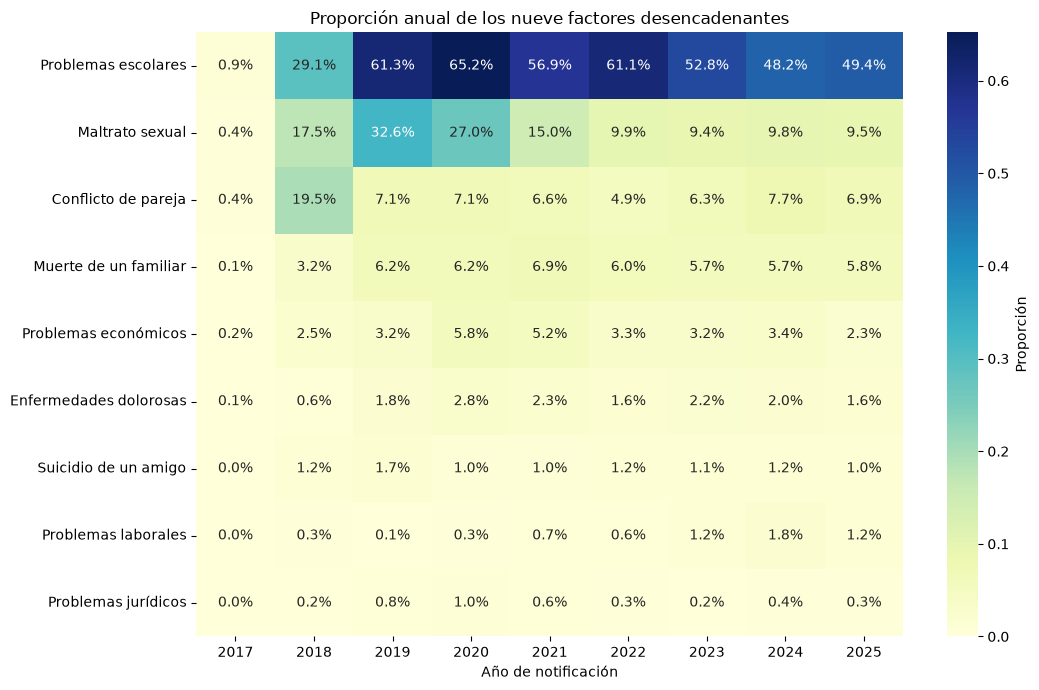

In [14]:
resumen_global, resumen_anual = calcular_indicadores(datos_estudio)

print("Frecuencias anuales de los nueve factores")
tabla_frecuencias = resumen_anual.pivot(index="Año", columns="factor", values="Frecuencia")
display(tabla_frecuencias)

grafico_mapa_calor_anual(resumen_anual)

El mapa de calor compara la proporción anual de los nueve factores. Los colores de mayor intensidad representan una mayor proporción de notificaciones con el factor marcado. Los problemas escolares predominan durante la mayor parte del periodo, seguidos por el maltrato sexual. Las proporciones varían entre años porque se calculan utilizando como denominador el total anual de notificaciones.

Frecuencia y proporción global


,Factor,Frecuencia,Proporción (%)
0,Problemas escolares,27243,50.56
1,Maltrato sexual,6899,12.80
2,Conflicto de pareja,3832,7.11
3,Muerte de un familiar,2965,5.50
4,Problemas económicos,1751,3.25
5,Enfermedades dolorosas,956,1.77
6,Suicidio de un amigo,598,1.11
7,Problemas laborales,491,0.91
8,Problemas jurídicos,199,0.37


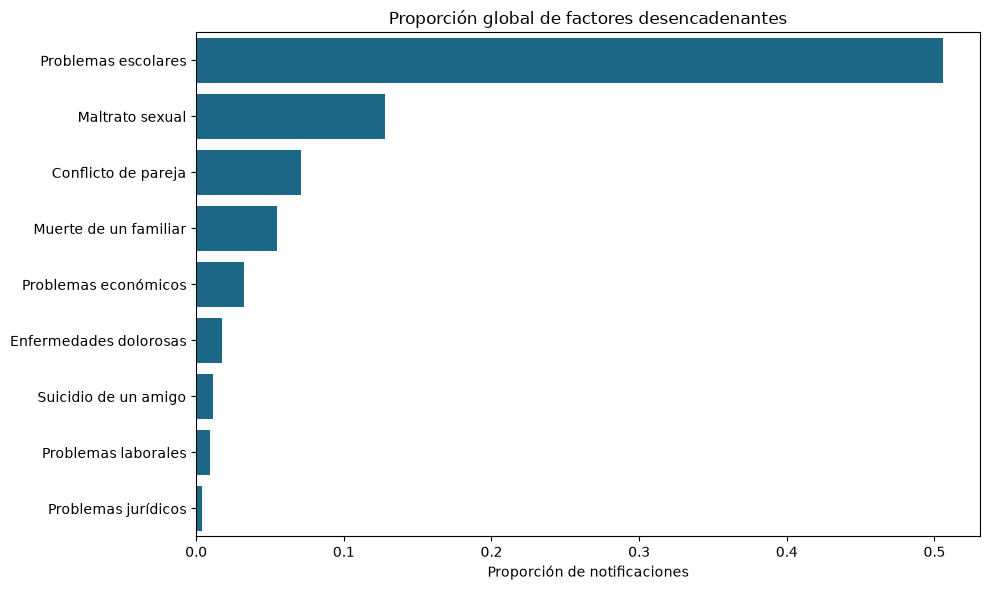

In [15]:
print("Frecuencia y proporción global")
resumen_global_mostrar = resumen_global[["Factor", "Frecuencia", "Proporción"]].copy()
resumen_global_mostrar["Proporción (%)"] = (
    resumen_global_mostrar.pop("Proporción") * 100
).round(2)
display(resumen_global_mostrar)

grafico_proporcion_global(resumen_global)

Los problemas escolares constituyen el factor con mayor presencia global, con 27.243 registros, equivalentes al 50,56 % del universo analizado. Le siguen el maltrato sexual, con 6.899 registros (12,80 %), y el conflicto de pareja, con 3.832 registros (7,11 %). Estos resultados permiten identificar inicialmente los tres factores predominantes. Las proporciones no deben sumarse para obtener el 100 %, porque una misma notificación puede presentar simultáneamente varios factores.

## 4. Primera prueba estadística: Q de Cochran

Se seleccionó la Q de Cochran porque los nueve factores analizados son variables binarias que solo toman valores de 0 y 1. Por esta razón, los datos no cumplen con los supuestos de normalidad requeridos por las pruebas paramétricas. Además, los factores están relacionados porque se encuentran medidos sobre las mismas notificaciones.

La Q de Cochran permite comparar conjuntamente más de dos variables binarias relacionadas y determinar si la proporción de registros con valor 1 es igual en los nueve factores. Su resultado permite identificar si existe una diferencia general entre ellos, aunque no señala específicamente cuáles factores son diferentes.

- **H₀:** los nueve factores presentan la misma proporción de registros con valor 1.
- **H₁:** al menos uno de los factores presenta una proporción diferente.
- **Regla de decisión:** con un nivel de significancia de α = 0,05, se rechaza H₀ cuando el p-valor es menor que 0,05.

In [16]:
resultado_cochran = prueba_cochran(datos_estudio, FACTORES)
display(resultado_cochran)

if resultado_cochran.loc[0, "Decisión"] == "Rechazar H0":
    print(
        "Conclusión: se rechaza H₀. Las proporciones de los nueve factores "
        "no son iguales; al menos un factor presenta una proporción diferente."
    )
else:
    print(
        "Conclusión: no se rechaza H₀. No se encontró evidencia suficiente "
        "para afirmar que las proporciones sean diferentes."
    )

,Estadístico Q,Grados de libertad,p-valor,N utilizado,Decisión
0,124083.018397,8,"< 0,001",53887,Rechazar H0


Conclusión: se rechaza H₀. Las proporciones de los nueve factores no son iguales; al menos un factor presenta una proporción diferente.


## 5. Ranking y selección de los factores principales

El ranking utiliza como criterio principal la proporción global descendente y como criterio secundario el número de años en el top 3. Los empates exactos se resuelven alfabéticamente. En cada año también se conservan exactamente tres factores y los empates se resuelven por nombre.

,Posición,Factor,Frecuencia,Años en top 3,Prioridad analítica,Proporción (%),Persistencia (%)
0,1,Problemas escolares,27243,9,Alta,50.56,100.00
1,2,Maltrato sexual,6899,9,Alta,12.80,100.00
2,3,Conflicto de pareja,3832,7,Alta,7.11,77.78
3,4,Muerte de un familiar,2965,2,Media,5.50,22.22
4,5,Problemas económicos,1751,0,Media,3.25,0.00
5,6,Enfermedades dolorosas,956,0,Media,1.77,0.00
6,7,Suicidio de un amigo,598,0,Baja,1.11,0.00
7,8,Problemas laborales,491,0,Baja,0.91,0.00
8,9,Problemas jurídicos,199,0,Baja,0.37,0.00


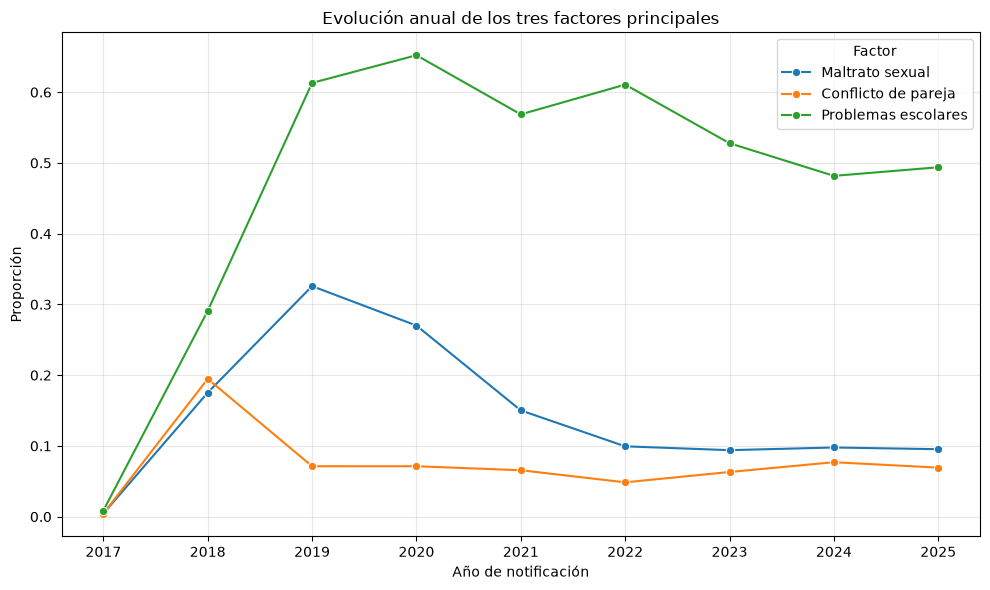

In [17]:
top3_anual = obtener_top3_anual(resumen_anual)
numero_anos = ANO_FINAL - ANO_INICIAL + 1
ranking = generar_ranking(resumen_global, top3_anual, numero_anos)

ranking_mostrar = ranking.drop(columns="factor").copy()
ranking_mostrar["Proporción (%)"] = (
    ranking_mostrar.pop("Proporción") * 100
).round(2)
ranking_mostrar["Persistencia (%)"] = (
    ranking_mostrar.pop("Persistencia") * 100
).round(2)
display(ranking_mostrar)

factores_top3 = ranking.head(3)["factor"].tolist()
grafico_evolucion_top3(resumen_anual, factores_top3)

La evolución anual confirma el predominio de los problemas escolares. Su mayor proporción se presenta en 2020, cuando aparece en el 65,22 % de las notificaciones, mientras que su mayor frecuencia se registra en 2022, con 5.652 casos. El maltrato sexual alcanza su proporción más alta en 2019 y el conflicto de pareja presenta un comportamiento más variable. Este último no pertenece al top 3 anual en 2021 ni en 2022, cuando es superado por la muerte de un familiar.

## 6. Segunda prueba estadística: McNemar

Después de comprobar con la Q de Cochran que existen diferencias generales entre los nueve factores, se seleccionó la prueba de McNemar para comparar por parejas los tres factores principales: problemas escolares, maltrato sexual y conflicto de pareja.

Esta prueba es adecuada porque los factores son variables binarias, con valores de 0 y 1, y están medidos sobre las mismas notificaciones. Por lo tanto, las observaciones de cada pareja están relacionadas y no deben analizarse como grupos independientes.

Para cada comparación, McNemar construye una tabla de contingencia de 2 × 2:

| Factor A / Factor B | Factor B = 0 | Factor B = 1 |
|---|---:|---:|
| **Factor A = 0** | Ninguno está presente | Solo está presente el factor B |
| **Factor A = 1** | Solo está presente el factor A | Ambos están presentes |

La prueba se concentra en los casos discordantes, es decir, las notificaciones en las que solo está presente uno de los dos factores. Compara la cantidad de registros donde aparece únicamente el factor A con la cantidad donde aparece únicamente el factor B. Si estas cantidades son significativamente diferentes, se concluye que los dos factores no presentan la misma proporción.

- **H₀ de cada pareja:** los dos factores presentan la misma proporción de registros con valor 1.
- **H₁ de cada pareja:** los dos factores presentan proporciones diferentes.
- **Regla de decisión:** se rechaza H₀ cuando el p-valor ajustado mediante Holm es menor que 0,05.

Como el top 3 genera tres comparaciones por parejas, se aplica el ajuste de Holm para controlar el aumento del riesgo de encontrar diferencias significativas por realizar varias pruebas. Las diferencias identificadas son estadísticas y no demuestran que los factores sean causas de la ideación suicida.

In [18]:
if resultado_cochran.loc[0, "Decisión"] == "Rechazar H0":
    resultados_mcnemar = comparar_mcnemar(
        datos_estudio,
        factores_top3
    )
    display(resultados_mcnemar)

    if (resultados_mcnemar["Decisión"] == "Rechazar H0").all():
        print(
            "Conclusión: se rechaza H₀ en las tres comparaciones. Los tres "
            "factores principales presentan proporciones estadísticamente diferentes."
        )
    else:
        print(
            "Conclusión: no todas las parejas presentan diferencias "
            "estadísticamente significativas después del ajuste de Holm."
        )
else:
    print(
        "McNemar no se aplica porque Cochran no rechazó "
        "la igualdad general."
    )

,Factor A,Factor B,Estadístico,p-valor,N utilizado,p-valor ajustado (Holm),Decisión
0,Problemas escolares,Maltrato sexual,13784.479682,"< 0,001",53887,"< 0,001",Rechazar H0
1,Problemas escolares,Conflicto de pareja,18847.477388,"< 0,001",53887,"< 0,001",Rechazar H0
2,Maltrato sexual,Conflicto de pareja,930.451945,"< 0,001",53887,"< 0,001",Rechazar H0


Conclusión: se rechaza H₀ en las tres comparaciones. Los tres factores principales presentan proporciones estadísticamente diferentes.


## 7. Verificación del escenario de fallo

La ejecución normal del notebook evidencia el escenario exitoso. Para comprobar el control de fallo pactado, se elimina deliberadamente la variable `maltrato_sexual`. La validación debe detener el proceso e identificar la columna ausente.

In [19]:
datos_incompletos = datos_seleccionados.drop(columns=["maltrato_sexual"])

try:
    validar_datos(datos_incompletos)
except ValueError as error:
    print(f"Escenario de fallo controlado correctamente: {error}")

Escenario de fallo controlado correctamente: Faltan columnas requeridas: maltrato_sexual


## 8. Resultado y conclusiones

In [20]:
principales = ranking.head(3)[["Factor", "Años en top 3", "Proporción"]]

print("Los factores que deben priorizarse para el análisis y seguimiento son:")
for _, fila in principales.iterrows():
    print(
        f"- {fila['Factor']}: {fila['Proporción']:.2%} de las notificaciones "
        f"y presencia en el top 3 durante {int(fila['Años en top 3'])} de "
        f"{numero_anos} años."
    )

print()
print(
    "Conclusión general: los problemas escolares presentan el predominio más "
    "claro y persistente, seguidos por el maltrato sexual y el conflicto de "
    "pareja. La priorización es descriptiva y no representa causalidad ni "
    "prioridad clínica."
)

Los factores que deben priorizarse para el análisis y seguimiento son:
- Problemas escolares: 50.56% de las notificaciones y presencia en el top 3 durante 9 de 9 años.
- Maltrato sexual: 12.80% de las notificaciones y presencia en el top 3 durante 9 de 9 años.
- Conflicto de pareja: 7.11% de las notificaciones y presencia en el top 3 durante 7 de 9 años.

Conclusión general: los problemas escolares presentan el predominio más claro y persistente, seguidos por el maltrato sexual y el conflicto de pareja. La priorización es descriptiva y no representa causalidad ni prioridad clínica.
